In [1]:
import os
from glob import glob

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
# =====================
# Paths
# =====================
wd_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"
output_dir = "./"
os.makedirs(output_dir, exist_ok=True)

# =====================
# Load REZ mask
# =====================
rez = xr.open_dataset(rez_file)["rez_mask"]
rez_valid = np.isfinite(rez)

# Match grids
rez_lat = rez.latitude
rez_lon = rez.longitude



In [3]:
# =====================
# Helper
# =====================
def compute_affected_mean_days_for_year(wd_da, rez_valid_da):
    """
    wd_da: DataArray, shape (time, latitude, longitude), 0/1 drought mask
    rez_valid_da: DataArray, same lat/lon grid, bool mask for REZ cells

    Returns:
        mean_days_affected: float
        n_affected_cells: int
        median_days_affected: float
    """
    # Annual drought days per grid cell
    drought_days = wd_da.sum(dim="time")

    # Keep only REZ cells
    drought_days_rez = drought_days.where(rez_valid_da)

    # Only cells that experienced at least one drought day
    affected = drought_days_rez.where(drought_days_rez > 0)

    vals = affected.values
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        return np.nan, 0, np.nan

    return float(np.mean(vals)), int(vals.size), float(np.median(vals))



In [4]:
# =====================
# Loop through yearly files
# =====================
files = sorted(glob(os.path.join(wd_dir, "wind_drought_P20_3day_*.nc")))

years = []
mean_days = []
median_days = []
n_affected_cells = []

for fp in files:
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing {year} ...", flush=True)

    ds = xr.open_dataset(fp)
    wd = ds["wind_drought"].load()
    ds.close()

    # Match REZ grid exactly
    wd = wd.sel(latitude=rez_lat, longitude=rez_lon)

    # Compute statistics for REZ cells that experienced drought
    mean_d, n_cells, median_d = compute_affected_mean_days_for_year(wd, rez_valid)

    years.append(year)
    mean_days.append(mean_d)
    median_days.append(median_d)
    n_affected_cells.append(n_cells)



Processing 1990 ...
Processing 1991 ...
Processing 1992 ...
Processing 1993 ...
Processing 1994 ...
Processing 1995 ...
Processing 1996 ...
Processing 1997 ...
Processing 1998 ...
Processing 1999 ...
Processing 2000 ...
Processing 2001 ...
Processing 2002 ...
Processing 2003 ...
Processing 2004 ...
Processing 2005 ...
Processing 2006 ...
Processing 2007 ...
Processing 2008 ...
Processing 2009 ...
Processing 2010 ...
Processing 2011 ...
Processing 2012 ...
Processing 2013 ...
Processing 2014 ...
Processing 2015 ...
Processing 2016 ...
Processing 2017 ...
Processing 2018 ...
Processing 2019 ...
Processing 2020 ...
Processing 2021 ...
Processing 2022 ...
Processing 2023 ...
Processing 2024 ...
Processing 2025 ...


In [5]:
# =====================
# Build table
# =====================
df = pd.DataFrame({
    "year": years,
    "mean_annual_drought_days_affected_cells": mean_days,
    "median_annual_drought_days_affected_cells": median_days,
    "n_affected_cells": n_affected_cells
})




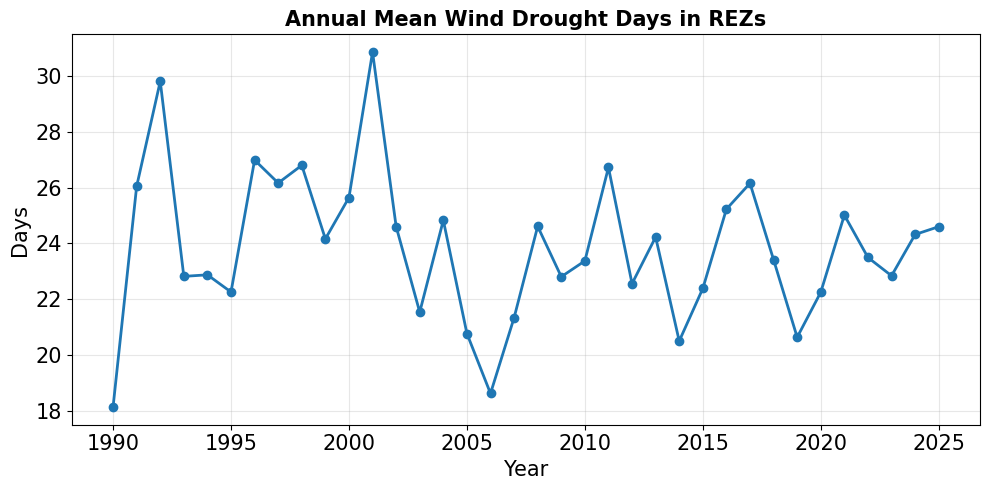

Saved: ./REZ_affected_cells_mean_annual_wind_drought_days_timeseries.png


In [9]:
# =====================
# Plot yearly time series
# =====================
plt.figure(figsize=(10, 5))
plt.plot(
    df["year"],
    df["mean_annual_drought_days_affected_cells"],
    marker="o",
    lw=2
)

# xy tick labels size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel("Year", fontsize=15)
plt.ylabel("Days", fontsize=15)
plt.title(
    "Annual Mean Wind Drought Days in REZs",
    fontsize=15,fontweight="bold"
)
plt.grid(alpha=0.3)
plt.tight_layout()

png_out = os.path.join(output_dir, "REZ_affected_cells_mean_annual_wind_drought_days_timeseries.png")
plt.savefig(png_out, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {png_out}")